In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
# Load the dataset
file_path = "Fina_SHIMP Data.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1", header=1)
df.head()  

,Demographic Info,Unnamed: 1,HIMP Run 1,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,HIMP Run 2,Unnamed: 9,...,Unnamed: 40,Unnamed: 41,Unnamed: 42,Unnamed: 43,SHIMP Run 2.1,Unnamed: 45,Unnamed: 46,Unnamed: 47,Unnamed: 48,Unnamed: 49
0,ID,Age/Sex,RL,LL,RA,LP,LA,RP,RL,LL,...,RA,LP,LA,RP,RL,LL,RA,LP,LA,RP
1,VSHIMP098,25/F,1.13,1.15,1.43,1.98,0.87,1.06,1.14,1.14,...,1.47,1.5,0.77,1.03,1.2,1.07,1.23,1.14,0.99,1.65
2,VSHIMP997,24/F,1.16,1.15,1.23,1.43,1.11,0.99,1.12,1.18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,VSHIMP_P001,22/F,1.02,1.04,1.61,1.36,0.9,0.97,1.03,1.09,...,1.56,1.1,1.04,1,1,0.98,0.72,0.96,1.29,1.39
4,VSHIMP002,23/F,1.15,1.09,1.3,1.35,1.13,1.16,1.09,1.13,...,1.03,1.25,0.89,1.16,0.89,0.92,0.84,1.08,1.14,1.22


In [3]:
df = pd.read_excel(file_path, sheet_name="Sheet1", header=2)
df.head()  

,ID,Age/Sex,RL,LL,RA,LP,LA,RP,RL.1,LL.1,...,RA.6,LP .1,LA.6,RP.6,RL.7,LL.7,RA.7,LP.5,LA.7,RP.7
0,VSHIMP098,25/F,1.13,1.15,1.43,1.98,0.87,1.06,1.14,1.14,...,1.47,1.50,0.77,1.03,1.20,1.07,1.23,1.14,0.99,1.65
1,VSHIMP997,24/F,1.16,1.15,1.23,1.43,1.11,0.99,1.12,1.18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,VSHIMP_P001,22/F,1.02,1.04,1.61,1.36,0.90,0.97,1.03,1.09,...,1.56,1.10,1.04,1.00,1.00,0.98,0.72,0.96,1.29,1.39
3,VSHIMP002,23/F,1.15,1.09,1.30,1.35,1.13,1.16,1.09,1.13,...,1.03,1.25,0.89,1.16,0.89,0.92,0.84,1.08,1.14,1.22
4,VSHIMP003,24/F,0.99,0.99,1.54,1.38,1.33,1.23,1.14,1.15,...,1.00,1.02,0.99,1.04,0.81,0.90,0.90,0.92,1.02,0.93


In [4]:
df.columns


Index(['ID', 'Age/Sex', 'RL', 'LL', 'RA', 'LP', 'LA', 'RP', 'RL.1', 'LL.1',
       'RA.1', 'LP.1', 'LA.1', 'RP.1', 'RL.2', 'LL.2', 'RA.2', 'LP ', 'LA.2',
       'RP.2', 'RL.3', 'LL.3', 'RA.3', 'LP.2', 'LA.3', 'RP.3', 'RL.4', 'LL.4',
       'RA.4', 'LP.3', 'LA.4', 'RP.4', 'RL.5', 'LL.5', 'RA.5', 'LP.4', 'LA.5',
       'RP.5', 'RL.6', 'LL.6', 'RA.6', 'LP .1', 'LA.6', 'RP.6', 'RL.7', 'LL.7',
       'RA.7', 'LP.5', 'LA.7', 'RP.7'],
      dtype='str')

In [5]:
# parse HIMP data only
canals = ["RL", "LL", "RA", "LP", "LA", "RP"]
himp_blocks = {
    ("W1", "Right"): range(2,8),
    ("W1", "Left"): range(8,14),
    ("W2", "Right"): range(26,32),
    ("W2", "Left"): range(32,38),
}
records = []

for i in range(3, len(df)):
    participant_id = df.iloc[i, 0]
    age_sex = df.iloc[i,1]

    if pd.isna(participant_id):
        continue
    for (week, camera_side), cols in himp_blocks.items():
        for canal, col in zip(canals, cols):
            gain = df.iloc[i, col]

            if pd.notna(gain):
                records.append({
                    "participant_id": participant_id,
                    "age_sex": age_sex,
                    "week": week,
                    "camera_side": camera_side,
                    "canal": canal,
                    "raw_himp_gain": gain
                })

df_himp = pd.DataFrame(records)

# split age_sex into separate age and sex columns
age_sex_split = df_himp["age_sex"].astype(str).str.extract(r"^\s*(?P<age>\d{1,3})\s*[/\-]?\s*(?P<sex>[A-Za-z]+)\s*$")
df_himp["age"] = pd.to_numeric(age_sex_split["age"], errors="coerce")
df_himp["sex"] = age_sex_split["sex"].str.strip().str.upper().str[:1]
df_himp.drop(columns=["age_sex"], inplace=True)
df_himp

,participant_id,week,camera_side,canal,raw_himp_gain,age,sex
0,VSHIMP002,W1,Right,RL,1.15,23,F
1,VSHIMP002,W1,Right,LL,1.09,23,F
2,VSHIMP002,W1,Right,RA,1.3,23,F
3,VSHIMP002,W1,Right,LP,1.35,23,F
4,VSHIMP002,W1,Right,LA,1.13,23,F
...,...,...,...,...,...,...,...
356,VSHIMP_P016,W2,Left,LL,0.94,33,F
357,VSHIMP_P016,W2,Left,RA,1.11,33,F
358,VSHIMP_P016,W2,Left,LP,1.1,33,F
359,VSHIMP_P016,W2,Left,LA,1.43,33,F


In [6]:
# df_himp.drop(columns=df_himp.columns[1])

In [7]:
# Feature engineering
# if RL or LL => horizontal canal, else vertical
df_himp["canal_type"] = np.where(df_himp["canal"].isin(["RL", "LL"]), "Horizontal", "Vertical")

# inflate pairs: Right camera should have RA and LP, Left camera should have LA and RP
# inflated_pair_flag = 1 if it's an inflated pair, else 0,
# means we expect gain to be higher than 1 for these pairs due to camera placement bias
# Right camera + RA/LP = inflated
# Left camera + LA/RP = inflated
df_himp["inflated_pair_flag"] = np.where(
    ((df_himp["camera_side"] == "Right") & (df_himp["canal"].isin(["RA", "LP"]))) |
    ((df_himp["camera_side"] == "Left") & (df_himp["canal"].isin(["LA", "RP"]))),
    1, 0
)
df_himp['healthy_center'] = 1.0

# ensure raw_himp_gain is numeric before subtracting
df_himp["raw_himp_gain"] = pd.to_numeric(df_himp["raw_himp_gain"], errors="coerce")
df_himp = df_himp.dropna(subset=["raw_himp_gain"]).copy()
for col in ["week", "camera_side", "canal", "canal_type"]:
    df_himp[col] = df_himp[col].fillna("Unknown")
df_himp["inflated_pair_flag"] = df_himp["inflated_pair_flag"].fillna(0)
df_himp["bias_from_1"] = df_himp["raw_himp_gain"] - df_himp["healthy_center"]
df_himp


,participant_id,week,camera_side,canal,raw_himp_gain,age,sex,canal_type,inflated_pair_flag,healthy_center,bias_from_1
0,VSHIMP002,W1,Right,RL,1.15,23,F,Horizontal,0,1.0,0.15
1,VSHIMP002,W1,Right,LL,1.09,23,F,Horizontal,0,1.0,0.09
2,VSHIMP002,W1,Right,RA,1.30,23,F,Vertical,1,1.0,0.30
3,VSHIMP002,W1,Right,LP,1.35,23,F,Vertical,1,1.0,0.35
4,VSHIMP002,W1,Right,LA,1.13,23,F,Vertical,0,1.0,0.13
...,...,...,...,...,...,...,...,...,...,...,...
356,VSHIMP_P016,W2,Left,LL,0.94,33,F,Horizontal,0,1.0,-0.06
357,VSHIMP_P016,W2,Left,RA,1.11,33,F,Vertical,0,1.0,0.11
358,VSHIMP_P016,W2,Left,LP,1.10,33,F,Vertical,0,1.0,0.10
359,VSHIMP_P016,W2,Left,LA,1.43,33,F,Vertical,1,1.0,0.43


In [8]:
# baseline summary before correction
summary_before = df_himp.groupby(["camera_side", "canal"])["raw_himp_gain"].agg(
    count="count",
    mean="mean",
    std="std",
    min="min",
    max="max"
).reset_index()

summary_before

,camera_side,canal,count,mean,std,min,max
0,Left,LA,30,1.466000,0.197302,0.99,1.92
1,Left,LL,30,1.099000,0.074572,0.92,1.23
2,Left,LP,30,1.244333,0.111593,1.10,1.59
3,Left,RA,30,1.225333,0.109568,1.05,1.50
4,Left,RL,30,1.037000,0.099556,0.81,1.21
5,Left,RP,30,1.514667,0.190837,1.15,1.87
6,Right,LA,30,1.229333,0.242301,0.89,2.11
7,Right,LL,30,1.055333,0.102343,0.85,1.28
8,Right,LP,30,1.333000,0.109612,1.07,1.58
9,Right,RA,30,1.398333,0.165719,1.07,1.68


In [9]:
# define ML target
# we are not forcing gain to exactly 1, but rather trying to predict the bias from 1, 
# which allows for more flexibility in the model and accounts for natural variability in healthy individuals. 
# The target variable is "bias_from_1", which represents how much the raw HIMP gain deviates from 
# the ideal healthy center of 1. This way, the model can learn to predict both positive and negative deviations, 
# rather than being constrained to only predict values that would correct to exactly 1. 
# This approach is more realistic and can capture a wider range of potential outcomes in the data.


target = "bias_from_1"
features = [
    "raw_himp_gain",
    #"week",
    "camera_side",
    "canal",
    "canal_type",
    "inflated_pair_flag",
]

X = df_himp[features]
y = df_himp[target]

groups = df_himp["participant_id"]


In [10]:
X

,raw_himp_gain,camera_side,canal,canal_type,inflated_pair_flag
0,1.15,Right,RL,Horizontal,0
1,1.09,Right,LL,Horizontal,0
2,1.30,Right,RA,Vertical,1
3,1.35,Right,LP,Vertical,1
4,1.13,Right,LA,Vertical,0
...,...,...,...,...,...
356,0.94,Left,LL,Horizontal,0
357,1.11,Left,RA,Vertical,0
358,1.10,Left,LP,Vertical,0
359,1.43,Left,LA,Vertical,1


In [11]:
# target variable = bias_from_1
y

0      0.15
1      0.09
2      0.30
3      0.35
4      0.13
       ... 
356   -0.06
357    0.11
358    0.10
359    0.43
360    0.18
Name: bias_from_1, Length: 360, dtype: float64

In [12]:
groups

0        VSHIMP002
1        VSHIMP002
2        VSHIMP002
3        VSHIMP002
4        VSHIMP002
          ...     
356    VSHIMP_P016
357    VSHIMP_P016
358    VSHIMP_P016
359    VSHIMP_P016
360    VSHIMP_P016
Name: participant_id, Length: 360, dtype: str

In [13]:
# Build Ridge Regression Model
numeric_features = ["raw_himp_gain", "inflated_pair_flag"]
categorical_features = [#"week",
                         "camera_side", "canal", "canal_type"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

ridge_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", Ridge(alpha=1.0))
])

In [14]:
# Cross validation for participant-level data
cv = GroupKFold(n_splits=5)
mae_scores = -cross_val_score(
    ridge_model, X, y, 
    groups=groups, 
    cv=cv,
    scoring="neg_mean_absolute_error")

In [15]:
print("Ridge CV MAE:", mae_scores)
print("Mean Ridge CV MAE:", mae_scores.mean())

Ridge CV MAE: [0.00098999 0.00074091 0.00062017 0.00090995 0.00075825]
Mean Ridge CV MAE: 0.0008038540222018055


In [16]:
# Train model ridge
ridge_model.fit(X,y)
df_himp["predicted_bias"] = ridge_model.predict(X)

# soft correction approachL remove only 80% of the predicted bias, 
# which allows for a more gradual correction and accounts for potential model imperfections.
correction_strength = 0.80

df_himp["corrected_himp_gain"] = df_himp["raw_himp_gain"] - correction_strength * df_himp["predicted_bias"]

# safety check optional to avoid unrealistic corrections
df_himp["corrected_himp_gain"] = df_himp["corrected_himp_gain"].clip(lower=0.65, upper=1.35)
df_himp.head()

,participant_id,week,camera_side,canal,raw_himp_gain,age,sex,canal_type,inflated_pair_flag,healthy_center,bias_from_1,predicted_bias,corrected_himp_gain
0,VSHIMP002,W1,Right,RL,1.15,23,F,Horizontal,0,1.0,0.15,0.149411,1.030471
1,VSHIMP002,W1,Right,LL,1.09,23,F,Horizontal,0,1.0,0.09,0.089829,1.018137
2,VSHIMP002,W1,Right,RA,1.30,23,F,Vertical,1,1.0,0.30,0.300500,1.059600
3,VSHIMP002,W1,Right,LP,1.35,23,F,Vertical,1,1.0,0.35,0.350089,1.069929
4,VSHIMP002,W1,Right,LA,1.13,23,F,Vertical,0,1.0,0.13,0.130577,1.025539


In [17]:
# Evaluate before vs after correction
before_mae = mean_absolute_error(df_himp["healthy_center"], df_himp["raw_himp_gain"])
after_mae = mean_absolute_error(df_himp["healthy_center"], df_himp["corrected_himp_gain"])

before_rmse = mean_squared_error(df_himp["healthy_center"], df_himp["raw_himp_gain"]) ** 0.5
after_rmse = mean_squared_error(df_himp["healthy_center"], df_himp["corrected_himp_gain"]) ** 0.5

print(f"Before Correction - MAE: {before_mae:.4f}, RMSE: {before_rmse:.4f}")
print(f"After Correction - MAE: {after_mae:.4f}, RMSE: {after_rmse:.4f}")
print("Before RMSE from 1.0: ", before_rmse)
print("After RMSE from 1.0: ", after_rmse)
print("Improvement %", (before_mae - after_mae) / before_mae * 100)

Before Correction - MAE: 0.2576, RMSE: 0.3233
After Correction - MAE: 0.0517, RMSE: 0.0650
Before RMSE from 1.0:  0.3233036927994757
After RMSE from 1.0:  0.06496485518661978
Improvement % 79.94762968572758


In [18]:
# canal-level evaluation

canal_eval = df_himp.groupby("canal").apply(lambda x: pd.Series({
    "before_mae_gain": x["raw_himp_gain"].mean(),
    "after_mae_gain": x["corrected_himp_gain"].mean(),
    "before_mae_from_1": np.mean(np.abs(np.abs(x["raw_himp_gain"] - 1.0))),
    "after_mae_from_1": np.mean(np.abs(np.abs(x["corrected_himp_gain"] - 1.0))),
    "n": len(x)
})).reset_index()
canal_eval

,canal,before_mae_gain,after_mae_gain,before_mae_from_1,after_mae_from_1,n
0,LA,1.347667,1.069546,0.355333,0.071323,60.0
1,LL,1.077167,1.015429,0.101833,0.020595,60.0
2,LP,1.288667,1.057729,0.288667,0.057729,60.0
3,RA,1.311833,1.062364,0.311833,0.062364,60.0
4,RL,1.063000,1.012595,0.101667,0.020662,60.0
5,RP,1.386500,1.077303,0.386500,0.077303,60.0


In [19]:
# 12. Camera-placement effect before vs after

placement_eval = df_himp.groupby(["camera_side", "canal"]).agg(
    before_mean=("raw_himp_gain", "mean"),
    after_mean=("corrected_himp_gain", "mean"),
    n=("raw_himp_gain", "count")
).reset_index()

placement_eval

,camera_side,canal,before_mean,after_mean,n
0,Left,LA,1.466000,1.093237,30
1,Left,LL,1.099000,1.019812,30
2,Left,LP,1.244333,1.049006,30
3,Left,RA,1.225333,1.045017,30
4,Left,RL,1.037000,1.007194,30
5,Left,RP,1.514667,1.103006,30
6,Right,LA,1.229333,1.045854,30
7,Right,LL,1.055333,1.011047,30
8,Right,LP,1.333000,1.066452,30
9,Right,RA,1.398333,1.079711,30


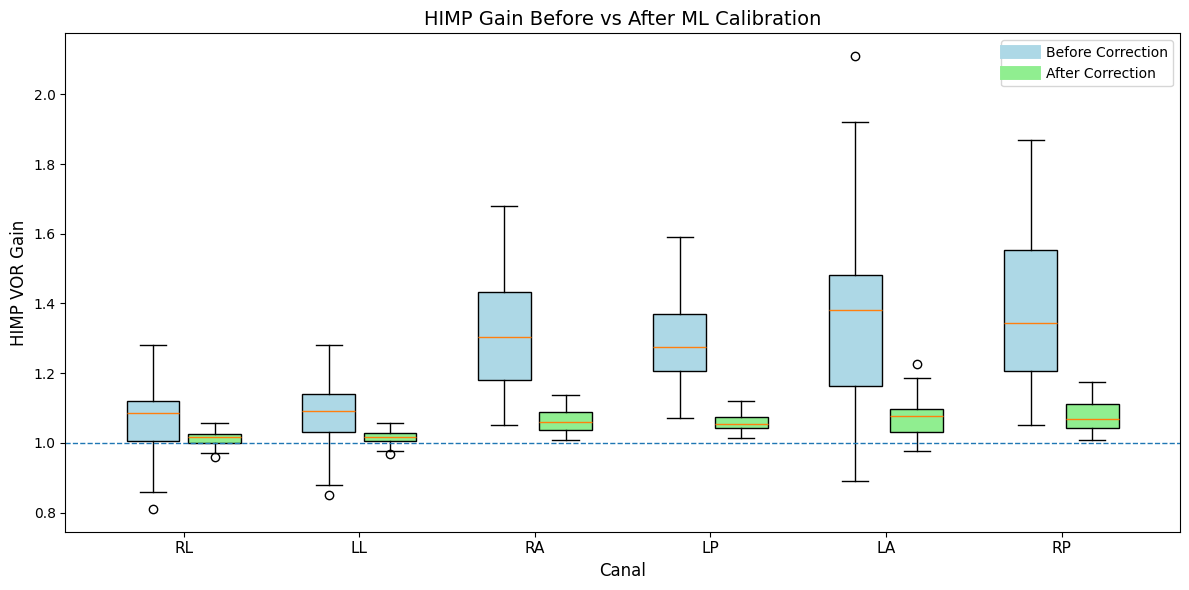

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Create plotting dataframe
plot_df = df_himp.melt(
    id_vars=["participant_id", 
             #"week", 
             "camera_side", "canal"],
    value_vars=["raw_himp_gain", "corrected_himp_gain"],
    var_name="gain_type",
    value_name="gain"
)

# Order canals properly
canal_order = ["RL", "LL", "RA", "LP", "LA", "RP"]

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(canal_order))
width = 0.35

before_data = [
    plot_df[
        (plot_df["canal"] == canal) &
        (plot_df["gain_type"] == "raw_himp_gain")
    ]["gain"]
    for canal in canal_order
]

after_data = [
    plot_df[
        (plot_df["canal"] == canal) &
        (plot_df["gain_type"] == "corrected_himp_gain")
    ]["gain"]
    for canal in canal_order
]

# Before correction
bp1 = ax.boxplot(
    before_data,
    positions=x - width/2,
    widths=0.3,
    patch_artist=True
)

# After correction
bp2 = ax.boxplot(
    after_data,
    positions=x + width/2,
    widths=0.3,
    patch_artist=True
)

# Colors
for patch in bp1['boxes']:
    patch.set_facecolor('lightblue')

for patch in bp2['boxes']:
    patch.set_facecolor('lightgreen')

# Labels and formatting
ax.set_xticks(x)
ax.set_xticklabels(canal_order, fontsize=11)

ax.axhline(1.0, linestyle="--", linewidth=1)

ax.set_ylabel("HIMP VOR Gain", fontsize=12)
ax.set_xlabel("Canal", fontsize=12)

ax.set_title("HIMP Gain Before vs After ML Calibration", fontsize=14)

# Manual legend
ax.plot([], [], color='lightblue', linewidth=10, label='Before Correction')
ax.plot([], [], color='lightgreen', linewidth=10, label='After Correction')

ax.legend()

plt.tight_layout()
plt.show()

In [21]:
# 14. Save corrected dataset

output_path = "himp_ml_corrected_results.csv"
df_himp.to_csv(output_path, index=False)

print("Saved:", output_path)

Saved: himp_ml_corrected_results.csv


In [22]:
week_analysis = df_himp.groupby("week")["raw_himp_gain"].agg(
    mean="mean",
    std="std",
    count="count"
)

print(week_analysis)

          mean       std  count
week                           
W1    1.259314  0.210859    204
W2    1.228141  0.208932    156


In [23]:
from scipy.stats import ttest_ind

w1 = df_himp[df_himp["week"] == "W1"]["raw_himp_gain"]
w2 = df_himp[df_himp["week"] == "W2"]["raw_himp_gain"]

t_stat, p_val = ttest_ind(w1, w2)

print("T-statistic:", t_stat)
print("P-value:", p_val)

T-statistic: 1.3954855855449617
P-value: 0.16373441890604903


In [24]:
import joblib

model_bundle = {
    "model": ridge_model,
    "features": [
        "raw_himp_gain",
        "camera_side",
        "canal",
        "canal_type",
        "inflated_pair_flag"
    ],
    "correction_strength": 0.80
}

joblib.dump(model_bundle, "himp_ridge_calibration_model.pkl")
print("Model saved.")

Model saved.


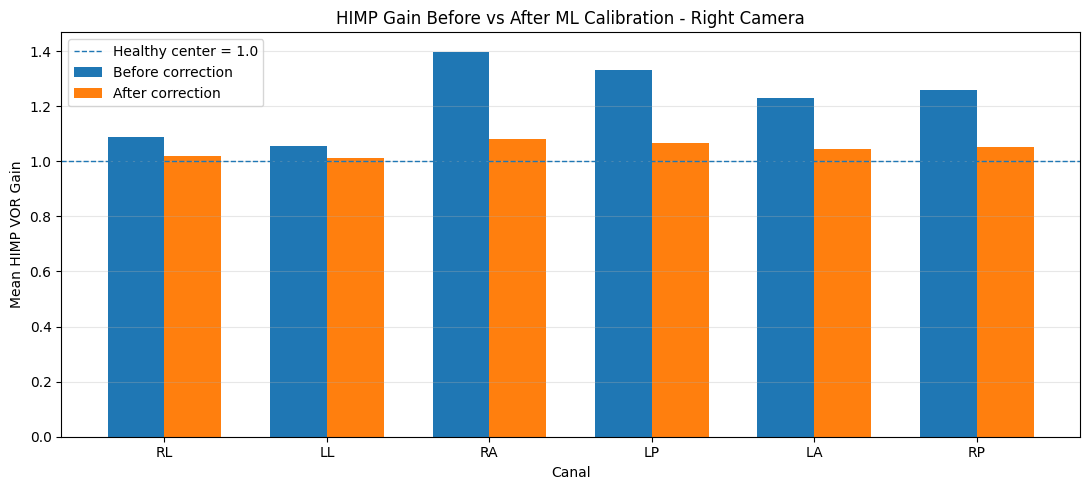

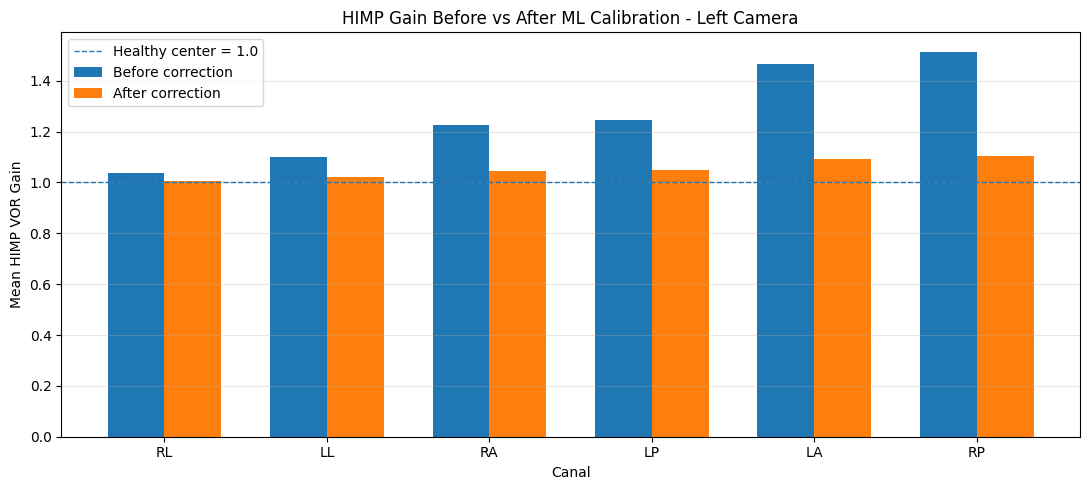

In [25]:
import matplotlib.pyplot as plt
import numpy as np

canal_order = ["RL", "LL", "RA", "LP", "LA", "RP"]
camera_order = ["Right", "Left"]

summary_plot = (
    df_himp
    .groupby(["camera_side", "canal"])
    .agg(
        before_mean=("raw_himp_gain", "mean"),
        after_mean=("corrected_himp_gain", "mean")
    )
    .reset_index()
)

for camera in camera_order:
    temp = summary_plot[summary_plot["camera_side"] == camera].copy()
    temp["canal"] = pd.Categorical(temp["canal"], categories=canal_order, ordered=True)
    temp = temp.sort_values("canal")

    x = np.arange(len(canal_order))
    width = 0.35

    fig, ax = plt.subplots(figsize=(11, 5))

    ax.bar(
        x - width/2,
        temp["before_mean"],
        width,
        label="Before correction"
    )

    ax.bar(
        x + width/2,
        temp["after_mean"],
        width,
        label="After correction"
    )

    ax.axhline(1.0, linestyle="--", linewidth=1, label="Healthy center = 1.0")

    ax.set_title(f"HIMP Gain Before vs After ML Calibration - {camera} Camera")
    ax.set_xlabel("Canal")
    ax.set_ylabel("Mean HIMP VOR Gain")
    ax.set_xticks(x)
    ax.set_xticklabels(canal_order)

    ax.legend()
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()